# The Telegraph Test - see it in 30 seconds

**Can language models write in telegraphese - and be understood?**

A real pair from the benchmark (a passage about the 1859 *Royal Charter* wreck inquiry - the actual telegraph era):

**Plain record** (mean 259 tokens): *The text describes an official inquiry into the wreck of the Royal Charter, a steam clipper ship. A commission was appointed...*

**Cablese record** (mean 117 tokens - **55% fewer**): *COMMISSION APPOINTED INQUIRE LOSS ROYAL CHARTER STEAM CLIPPER. SITTINGS LIVERPOOL FROM 6 FEBRUARY 1860 BEFORE MR TREMENHEERE ASSISTED CAPTAINS HARRIS...*

**The finding:** downstream models - including *other model families* (Google, Alibaba, NVIDIA, OpenAI) - read compressed records **as well as or better than** plain ones. Deterministic grading only; no LLM judges anywhere in the truth path.

*This notebook replays frozen results (no key, no cost). The optional live mode at the bottom compresses YOUR text if you bring an OpenRouter key.*

In [1]:
# One-time setup: clone the repo if needed (Colab opens this notebook without the repo)
import os, subprocess
if not os.path.exists('ab'):
    subprocess.run(['git', 'clone', '--depth', '1',
                    'https://github.com/Travis42/telegraph-test.git', 'tt'], check=True)
    os.chdir('tt')
print('workspace:', os.getcwd())


workspace: /root/clawd/telegraph-test


In [1]:
# Verify every headline number against the frozen artifacts (zero API calls)
import subprocess, sys
r = subprocess.run([sys.executable, 'verify_headlines.py'], capture_output=True, text=True)
print(r.stdout or r.stderr)


check                                                     computed   README  ok
------------------------------------------------------------------------------------
cbl2 savings_pct_v2 (README 54.6%)                          0.5462    0.546  OK
recovery_ratio_v2 (README 1.089)                            1.0889    1.088  OK
A-FROM-PLAIN acc (README 75.8%)                             0.7579    0.758  OK
A-FROM-CABLESE acc (README 82.5%)                           0.8253    0.825  OK
decode_ratio_v2 (README 0.862)                              0.8617    0.861  OK
xm4 reader R1 (google/gemma-4-31b-it)                       1.0935    1.095  OK
xm4 reader R2 (qwen/qwen3.8-27b)                            1.0976    1.097  OK
xm4 reader R3 (nvidia/nemotron-3-super-120b-a12b)           1.0076    1.004  OK
xm4 reader R4 (google/gemma-4-26b-a4b-it)                   1.0723    1.069  OK
xm4 writer W1 (google/gemma-4-31b-it) ratio                 1.0868    1.087  OK
xm4 writer W2 (qwen/qwen3.8-27b) ra

In [1]:
# A real record pair from the runs
import json, glob

def first_record(run, cond):
    for f in sorted(glob.glob('data/runs/%s/slices/*.jsonl' % run)):
        for line in open(f):
            r = json.loads(line)
            if r.get('type') == 'record' and r.get('condition') == cond:
                return r
    raise SystemExit('record not found')

plain = first_record('cablese_cbl2', 'R-PLAIN')
cabl = first_record('cablese_cbl2', 'R-CABLESE')
print('PLAIN (%d tokens):' % plain['approx_tokens'])
print(plain['text'][:550])
print()
print('CABLESE (%d tokens):' % cabl['approx_tokens'])
print(cabl['text'][:550])
print()
print('savings on this passage: %.0f%%' % (100 * (1 - cabl['approx_tokens'] / plain['approx_tokens'])))


PLAIN (711 tokens):
**Record of the Royal Charter Commission Text**

The text describes an official inquiry into the wreck of the Royal Charter, a steam clipper ship. A commission was appointed to investigate the loss, and it held its sittings at Liverpool, beginning on 6 February 1860. The proceedings were conducted before Mr. Tremenheere, who was assisted by Captains Harris and Gray, both of the Board of Trade.

The vessel itself was of 2,719 tons register and had been built on the Clyde at Sandycroft in 1855. On her final voyage she departed Melbourne on 26 Aug

CABLESE (405 tokens):
COMMISSION APPOINTED INQUIRE LOSS ROYAL CHARTER STEAM CLIPPER. SITTINGS LIVERPOOL FROM 6 FEBRUARY 1860 BEFORE MR TREMENHEERE ASSISTED CAPTAINS HARRIS AND GRAY OF BOARD OF TRADE. SHIP 2,719 TONS REGISTER BUILT CLYDE SANDYCROFT 1855. LEFT MELBOURNE 26 AUGUST 1859 CARRYING 388 PASSENGERS CREW 112 GENERAL CARGO INCLUDING 79,000 OUNCES GOLD IN 39 BOXES CONSIGNED LONDON BANKS. COMMAND CAPTAIN JOHN TAYLOR, WIT

ratios: {'R1': 1.093, 'R2': 1.098, 'R3': 1.008, 'R4': 1.072, 'W1': 1.087, 'W2': 1.099, 'W3': 0.992}


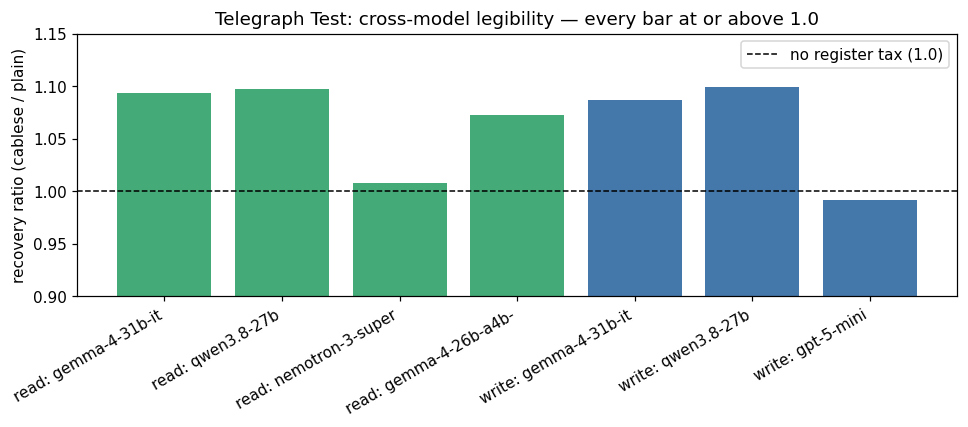

In [1]:
# Cross-family legibility: every ratio is cablese/plain accuracy (1.0 = no register tax)
import json
import matplotlib.pyplot as plt

xm = json.load(open('data/runs/crossmodel_xm4/summary.json'))
readers = {k: v['recovery_ratio'] for k, v in xm['direction_a'].items()}
writers = {k: v['recovery_ratio'] for k, v in xm['direction_b'].items()}

fig, ax = plt.subplots(figsize=(9, 4))
labels = ['read: ' + xm['direction_a'][k]['model'].split('/')[1][:16] for k in readers] \
       + ['write: ' + xm['direction_b'][k]['model'].split('/')[1][:16] for k in writers]
vals = list(readers.values()) + list(writers.values())
colors = ['#4a7'] * len(readers) + ['#47a'] * len(writers)
ax.bar(labels, vals, color=colors)
ax.axhline(1.0, color='k', lw=1, ls='--', label='no register tax (1.0)')
ax.set_ylabel('recovery ratio (cablese / plain)')
ax.set_ylim(0.9, 1.15)
ax.set_title('Telegraph Test: cross-model legibility — every bar at or above 1.0')
plt.xticks(rotation=30, ha='right'); plt.legend(); plt.tight_layout()
print('ratios:', {k: round(v, 3) for k, v in {**readers, **writers}.items()})


In [1]:
# The storage loop: write compressed, store compressed, expand for humans later
import json
rd = json.load(open('data/runs/record_decode_rd1/summary.json'))
acc = rd['conditions']['A-FROM-DECODED']['overall_raw']['accuracy']
src = rd['source_accuracies_v2']
tok = rd['record_tokens']
print('answer from PLAIN record:   %.3f' % src['A-FROM-PLAIN'])
print('answer from CABLESE record: %.3f' % src['A-FROM-CABLESE'])
print('answer from DECODED record: %.3f  (expanded back to English first)' % acc)
print()
print('tokens per record: plain %.0f | cablese %.0f | decoded %.0f' % (
    tok['R-PLAIN']['mean_approx_tokens'], tok['R-CABLESE']['mean_approx_tokens'],
    tok['R-DECODED']['mean_approx_tokens']))
print('decoded archive stays %.0f%% leaner than plain' % (100 * (1 - tok['decoded_vs_plain_ratio'])))


answer from PLAIN record:   0.755
answer from CABLESE record: 0.835
answer from DECODED record: 0.816  (expanded back to English first)

tokens per record: plain 260 | cablese 117 | decoded 155
decoded archive stays 40% leaner than plain


## How the comparisons are tested (McNemar, in plain words)

Every comparison is **paired** - the same questions under both conditions. Ignore the questions both got right or both got wrong (no signal); look only at the **exchanges**, where exactly one condition succeeded. If the conditions were equal, exchanges split like coin flips. The decoded-record vs plain-record exchanges: **69 wins to 45** - a split with only ~3% probability under pure chance (p=0.031). That is every p-value in this work.

## Grading integrity

An earlier version used an LLM to judge its own grading edge cases - the models graded their own homework generously. We caught it, deleted every judge-derived number, and rebuilt grading as deterministic, passage-anchored code (`ab/grade.py`; the story is in `docs/`). **No fidelity claim here survives on a model's own testimony.**

In [1]:
# LIVE (optional): compress YOUR text. Set YOUR_OPENROUTER_KEY, then run.
# Everything above this cell runs free on frozen data; this cell calls the API.
import os, json, urllib.request

YOUR_OPENROUTER_KEY = ""   # <- paste an OpenRouter key (https://openrouter.ai/keys)
MODEL = "google/gemma-4-31b-it"          # cheap; swap for any chat model
your_text = ("Paste a paragraph here - anything with facts, numbers, names. For example: "
             "The Beaumont-Hamel memorial stands on the Somme. It was dedicated in 1925 "
             "by Earl Haig and preserves the Newfoundland Regiment front-line trenches "
             "of 1 July 1916, when 780 men advanced and the next morning only 68 "
             "answered roll call.")

CABLESE_RULES = ("Write a complete record in telegraphese/cablese: drop articles, "
                 "filler and politeness; abbreviate freely; KEEP every fact, number, "
                 "and proper noun verbatim; do not add information; telegraphic density.")
DECODE_PROMPT = ("Expand the following cablese record back into plain English, using "
                 "ONLY this record. Keep every fact, number and proper noun exactly; "
                 "do not add information.")

def chat(messages, model=MODEL):
    req = urllib.request.Request(
        "https://openrouter.ai/api/v1/chat/completions",
        data=json.dumps({"model": model, "messages": messages, "max_tokens": 800}).encode(),
        headers={"Authorization": "Bearer " + YOUR_OPENROUTER_KEY,
                 "Content-Type": "application/json"})
    return json.loads(urllib.request.urlopen(req, timeout=120).read())["choices"][0]["message"]["content"]

if not YOUR_OPENROUTER_KEY:
    print("Set YOUR_OPENROUTER_KEY above to run the live demo.")
else:
    cablese = chat([{"role": "system", "content": CABLESE_RULES},
                    {"role": "user", "content": your_text}])
    expanded = chat([{"role": "user", "content": DECODE_PROMPT + "\n\n" + cablese}])
    print("ORIGINAL:\n", your_text[:400])
    print("\nCABLESE:\n", cablese)
    print("\nEXPANDED:\n", expanded)
    print("\nchars: original %d -> cablese %d (%.0f%% shorter)" % (
        len(your_text), len(cablese), 100 * (1 - len(cablese) / len(your_text))))


Set YOUR_OPENROUTER_KEY above to run the live demo.


## Links

- Repo & frozen data: `Travis42/telegraph-test` (this repository)
- Write-up: *The Telegraph Test: What 19th-Century Cable Codes Know About LLM Token Economics* (fiveminutesforward)
- License: Apache-2.0 (code) / CC-BY-4.0 (data)

*Named for the telegraph operators who ran this experiment first, ~150 years ago, for the same reason: metered words are expensive.*